# Resumen de las variables

*Las 12 covariables que entran al propensity score. Todo se mide entre el
2016-04-22 y el 2019-04-21, los tres años previos al tratamiento.*

## Estructurales (7)

Ponderadas por metros de vía dentro del círculo, no por máximos ni binarias:
un círculo con una avenida de 8 carriles y cuatro calles de 2 se describe por su
composición, no por su caso extremo.

| Variable | Qué es |
| --- | --- |
| `road_length_m` | metros de vía dentro del área |
| `n_vialidades` | vías distintas que la cruzan |
| `carriles_ponderados` | carriles promedio, pesado por metros |
| `pct_acceso_controlado` | fracción de los metros en vía de acceso controlado |
| `pct_doble_sentido` | fracción de los metros en vías de doble sentido |
| `pct_desnivel` | fracción de los metros en vía elevada o deprimida |
| `n_niveles` | niveles distintos que coexisten en el área |

`pct_desnivel` y `n_niveles` son nuevas: miden la ambigüedad vertical, el
problema de que un incidente registrado con solo latitud y longitud no dice si
ocurrió en el segundo piso o en la vía de abajo.

## Siniestralidad (4)

| Variable | Qué es |
| --- | --- |
| `nivel_incidentes` | tasa mensual promedio de los tres años |
| `pct_lesionados` | fracción con consecuencias personales: PIC y FCS juntos |
| `tendencia` | tasa del año -1 menos la del año -3 |
| `hubo_fcs` | si hubo algún incidente fatal en los tres años |

Son cuatro y no once porque las once medían casi lo mismo: correlaciones de 0.75
a 0.94 y un primer componente principal con el 85.5% de la varianza. Las que
quedaron son las dimensiones independientes — nivel, gravedad y tendencia — más
la binaria de fatales, que no es proxy del nivel (correlación 0.34) y es el
criterio declarado de ubicación de las cámaras.

**No hay curvatura ni desviaciones estándar.** Se midieron y resultaron ruido:
la curvatura tiene confiabilidad 0.33, y las SD correlacionan 0.92-0.94 con los
niveles porque en datos de conteo la varianza es aproximadamente la media.

## Metro (1)

| Variable | Qué es |
| --- | --- |
| `afluencia_nivel` | usuarios mensuales promedio de las estaciones dentro del área |

Una y no cuatro: las cuatro correlacionaban entre 0.984 y 1.000, con el 99.5% de
la varianza en un solo componente. El cero significa "no hay estación dentro",
que es informativo y no un dato faltante.

## Fuera, con razón documentada

| Qué | Por qué |
| --- | --- |
| Exposición vehicular (SICT) | una sola serie para toda la ciudad: no varía entre unidades y los efectos fijos de tiempo ya la absorben |
| `curvatura` de la siniestralidad | dos tercios ruido |
| Desviaciones estándar | miden tamaño otra vez, no volatilidad |
| `area_ha` | todas las unidades son círculos del mismo radio |
| Crecimiento de la afluencia | solo definido para el 14% con estación; va como robustez restringida a ese subconjunto |

## Reglas que aplican a todo

**Todo es pre-tratamiento.** Una variable medida antes de que existiera la cámara
no pudo ser causada por ella, así que no puede ser mediadora ni collider. Es la
defensa principal del diseño.

**Las ventanas son de 12 meses contados hacia atrás desde el 22 de abril**, no
años calendario, para que la más reciente termine justo antes del tratamiento.

**Todo en tasas mensuales**, incidentes y afluencia, para que el vector completo
se lea en la misma unidad temporal.

# Feature Design
Ahora tenemos que implementar los features que se utilizarán tanto en el cálculo del propensity score, como en el DiD. La pregunta clave aquí es, ¿por qué variables tengo que controlar? O dicho de otra forma, ¿cuáles son las variables que pueden afectar tanto a mi tratamiento como a mi outcome?  

Tipos de variables:
1. **Confusores**: causan tratamiento y outcome — Siempre se tienen que incluir, no hacerlo es incurrir en sesgo de selección. El ejemplo más obvio son los incidentes viales, el gobierno mismo declara haber puesto las cámaras en zonas con altos índices de accidentes, y claramente una zona con más accidentes en el pasado tendrá más accidentes en el futuro.
2. **Predictores solo del outcome** — No afectan al tratamiento. Conviene incluirlos, no introducen sesgo y reducen la varianza: explican el ruido del outcome. Son variables que hacen que sea más o menos probable que ocurra accidentes pero que no afectan la decisión de poner una cámara de velocidad.
3. **Predictores solo del tratamiento** — No afectan el outcome. Hay que excluirlos. Inflan la varianza y no reducen sesgo, y en el matching forzan hacer pares con una dimensión que no importa y empeoran el balance en las que sí.
4. **Variables posteriores al tratamiento** — No incluirlas jamás. Si una variable fue afectada por el tratamiento, controlarla te quita parte del efecto que quieres medir. Si es efecto común del tratamiento y del outcome, es un *collider*, y controlarlo crea correlación espuria donde no había. **Un colliders es una variable causada por dos cosas a la vez**. 

## Las ventanas

Todo se mide **antes** del 22 de abril de 2019. Esa es la regla que protege el
diseño: una variable medida antes de que existiera la cámara no pudo haber sido
causada por ella, así que no puede ser mediadora ni collider.

Los años se cuentan hacia atrás desde el tratamiento, no por año calendario:

| Ventana | Desde | Hasta |
| --- | --- | --- |
| `anio_1` | 2018-04-22 | 2019-04-21 |
| `anio_2` | 2017-04-22 | 2018-04-21 |
| `anio_3` | 2016-04-22 | 2017-04-21 |

Tres valores por variable en vez de un promedio: el nivel y la tendencia salen
de comparar las tres ventanas, sin tener que ajustar una recta ni imponer que la
evolución sea lineal.

In [1]:
from nbsetup import *
from pipeline import Datos, UnidadesTratadas

datos = Datos()

FECHA_TRATAMIENTO = pd.Timestamp("2019-04-22")
N_ANIOS = 3

VENTANAS = {
    f"anio_{k}": (
        FECHA_TRATAMIENTO - pd.DateOffset(years=k),
        FECHA_TRATAMIENTO - pd.DateOffset(years=k - 1),
    )
    for k in range(1, N_ANIOS + 1)
}

for nombre, (inicio, fin) in VENTANAS.items():
    print(f"{nombre}: {inicio:%Y-%m-%d} a {fin - pd.Timedelta(days=1):%Y-%m-%d}")

anio_1: 2018-04-22 a 2019-04-21
anio_2: 2017-04-22 a 2018-04-21
anio_3: 2016-04-22 a 2017-04-21


## Estructurales

Las versiones anteriores usaban máximos y binarias (`max_carriles`,
`both_directions`, `via_primaria`). El problema es que a 300 m casi cualquier
círculo contiene una avenida grande y una calle de doble sentido, así que esas
variables valen lo mismo en casi todas las unidades y no sirven para distinguir.

Aquí se ponderan por longitud: describen **la composición del área**, no su caso
extremo. Un círculo con una avenida de 8 carriles y cuatro calles de 2 deja de
resumirse como "8".

In [2]:
def features_estructurales(unidades, vialidades):
    """Composición vial de cada unidad, ponderada por metros de vía."""
    pares = gpd.sjoin(vialidades, unidades[["unidad_id", "geometry"]], predicate="intersects")

    # metros de cada vialidad que caen DENTRO del círculo, no su longitud total
    geom_unidad = unidades.set_index("unidad_id").geometry
    pares["metros"] = [
        via.intersection(geom_unidad.loc[uid]).length
        for via, uid in zip(pares.geometry, pares.unidad_id)
    ]
    pares = pares[pares.metros > 0]

    def pond(grupo, columna):
        """Promedio de `columna` pesado por metros."""
        return np.average(grupo[columna], weights=grupo.metros)

    filas = []
    for uid, g in pares.groupby("unidad_id"):
        total = g.metros.sum()
        filas.append({
            "unidad_id": uid,
            "road_length_m": total,
            "n_vialidades": g.ID_VIA.nunique(),
            "carriles_ponderados": pond(g, "CARRILES_num"),
            "pct_acceso_controlado": g.loc[g.TIPO_VIA == "Vía de acceso controlado", "metros"].sum() / total,
            "pct_doble_sentido": g.loc[g.doble_sentido, "metros"].sum() / total,
            "pct_desnivel": g.loc[g.NIVEL != 0, "metros"].sum() / total,
            "n_niveles": g.NIVEL.nunique(),
        })

    return (
        pd.DataFrame(filas)
        .set_index("unidad_id")
        .reindex(unidades.unidad_id)
        .fillna({"road_length_m": 0, "n_vialidades": 0, "carriles_ponderados": 0,
                 "pct_acceso_controlado": 0, "pct_doble_sentido": 0,
                 "pct_desnivel": 0, "n_niveles": 0})
    )


# el sentido viene como texto y los carriles como string: se preparan una vez
vialidades = datos.vialidades.assign(
    CARRILES_num=lambda x: pd.to_numeric(x.CARRILES, errors="coerce"),
    doble_sentido=lambda x: x.CIRCULA.isin(["Dos sentidos", "Un sentido con carril de contraflujo"]),
)

base = UnidadesTratadas(datos, radio_m=300)
estructurales = features_estructurales(base.unidades, vialidades)
estructurales.head()

,road_length_m,n_vialidades,carriles_ponderados,pct_acceso_controlado,pct_doble_sentido,pct_desnivel,n_niveles
unidad_id,,,,,,,
0,4512.891427,3,2.439163,0.613978,0.099952,0.102582,2
1,2702.058005,3,3.542458,0.393613,0.000000,0.000000,1
2,2331.534175,5,3.150756,0.085512,0.000000,0.294471,2
3,1791.566348,2,2.668816,0.000000,0.334408,0.000000,1
4,6264.543845,2,2.347429,0.793188,0.005829,0.512951,4


## Siniestralidad previa

Cuatro variables, no once. La primera versión tenía una tasa por cada nivel y
cada ventana, más binarias de fatales y desviaciones estándar. Medirlas mostró
que casi todas dicen lo mismo:

- Las ocho variables continuas correlacionan entre **0.75 y 0.94**.
- El primer componente principal explica el **85.5%** de la variación, y sus
  cargas son idénticas en todas (≈0.35, mismo signo): es **el nivel**, cuántos
  incidentes ocurren en esa zona.
- El segundo, con 6.5%, opone MIN contra PIC: es **la composición**.
- Las dos desviaciones estándar correlacionan 0.92–0.94 con los niveles. Eso
  tiene una explicación: en datos de conteo la varianza es aproximadamente igual
  a la media, así que no miden volatilidad, miden tamaño otra vez.

El problema de meterlas todas no es estadístico sino de prioridades. El
propensity score es un índice, y ocho variables apuntando a la misma dimensión
hacen que el nivel domine sobre las estructurales. Y sobre todo:

**La tendencia —lo único que sostiene el supuesto de tendencias paralelas— es
apenas el 6% de la señal.** Su correlación con el nivel es -0.07, o sea que es
información genuinamente independiente, pero su desviación estándar es 1.22
contra 3.02 del nivel. Emparejando con las once variables, el algoritmo iguala
niveles y la trayectoria le da casi igual. Estaría optimizando justo lo que los
efectos fijos ya resuelven, y descuidando lo que los efectos fijos no pueden
arreglar.

Por eso la tendencia se construye **explícitamente** como variable, en vez de
esperar que emerja de tres niveles anuales.

| Variable | Qué captura |
| --- | --- |
| `nivel_incidentes` | tasa mensual promedio de los tres años previos |
| `pct_lesionados` | fracción con consecuencias personales: PIC y FCS juntos |
| `tendencia` | tasa del año -1 menos la del año -3 |
| `hubo_fcs` | si hubo algún incidente fatal en los tres años |

**Los fatales cuentan dos veces, y a propósito.** Su tasa entra sumada a la de
lesionados dentro de `pct_lesionados`, y aparte se conserva `hubo_fcs`.

Sumarlos a PIC sale gratis: son el 0.5% de los incidentes, así que separarlos o
no mueve `nivel_incidentes` en 0.02 y `pct_lesionados` en 0.003. Y la categoría
resultante —"con consecuencias personales"— es más fácil de justificar que
"con lesionados, excluyendo muertos".

La binaria se conserva porque no es redundante con nada:

- Su correlación con el nivel es **0.34**. Hay zonas tranquilas donde murió
  alguien y zonas con muchos incidentes donde nadie murió: la probabilidad de
  haber tenido un fatal sube de 22% a 64% entre el cuartil más bajo y el más
  alto de siniestralidad, pero está lejos de quedar determinada.
- Aporta al propensity score. Con validación cruzada de 5 folds, el AUC para
  distinguir tratadas de controles pasa de **0.703 a 0.728** al agregarla.
- Y sobre todo: **los muertos son el criterio declarado de ubicación**. El
  gobierno dijo que las cámaras se pusieron en tramos con más muertos y
  lesionados, así que la presencia de un fatal previo está en el mecanismo de
  asignación del tratamiento, no es una covariable cualquiera.

Como tasa no funcionaría: entre 58% y 84% de las unidades no tuvieron ningún
fatal en una ventana anual, y una variable que es cero en cuatro de cada cinco
unidades hace que la mayoría de los pares se "igualen" en cero, que no es
información.

In [24]:
def features_incidentes(unidades, asignados):
    """Nivel, gravedad, tendencia y presencia de fatales, todo pre-tratamiento.

    Las tres primeras son las dimensiones que el análisis de componentes
    principales encontró en las once variables de la primera versión: nivel
    (85.5% de la varianza), composición (6.5%) y tendencia (ortogonal al nivel,
    correlación -0.07). Construirlas por separado evita que el nivel, que es la
    dimensión dominante, se lleve todo el peso del emparejamiento.

    Los fatales cuentan dentro de `pct_lesionados` en vez de ir aparte: son el
    0.5% de los incidentes, así que separarlos movía las variables en el tercer
    decimal, y la categoría "con lesionados, excluyendo muertos" es más difícil
    de justificar que "con consecuencias personales".
    """
    ventanas = {}
    for nombre, (inicio, fin) in VENTANAS.items():
        v = asignados[(asignados.timestamp >= inicio) & (asignados.timestamp < fin)]
        ventanas[nombre] = {
            nivel: (
                v[v.incident_level == nivel].groupby("unidad_id").peso.sum()
                .reindex(unidades.unidad_id, fill_value=0) / 12
            )
            for nivel in ("MIN", "PIC", "FCS")
        }

    total = {n: v["MIN"] + v["PIC"] + v["FCS"] for n, v in ventanas.items()}
    nivel = sum(total.values()) / len(total)
    con_lesionados = sum(v["PIC"] + v["FCS"] for v in ventanas.values()) / len(ventanas)
    fatales = sum(v["FCS"] for v in ventanas.values())

    return pd.DataFrame({
        "nivel_incidentes": nivel,
        # gravedad: fracción con consecuencias personales, fatales incluidos.
        # donde no hubo nada la composición no existe y va en 0
        "pct_lesionados": (con_lesionados / nivel.replace(0, np.nan)).fillna(0),
        # el año más reciente contra el más lejano: positivo = venía subiendo
        "tendencia": total["anio_1"] - total["anio_3"],
        # se conserva aparte porque no es un proxy del nivel (correlación 0.34) y
        # porque los muertos son el criterio declarado de ubicación de las cámaras
        "hubo_fcs": (fatales > 0).astype(int),
    })


incidentes = features_incidentes(base.unidades, base.incidentes_asignados)
incidentes.head()

,nivel_incidentes,pct_lesionados,tendencia,hubo_fcs
unidad_id,,,,
0,5.305556,0.450262,1.583333,0
1,10.111111,0.348901,1.750000,1
2,8.097222,0.439108,-0.166667,1
3,4.625000,0.549550,-1.166667,1
4,6.166667,0.277027,2.166667,1


### Por qué no hay una variable de curvatura

Tres puntos anuales tienen tres grados de libertad, y la base ortogonal natural
es nivel `(1,1,1)`, pendiente `(-1,0,1)` y curvatura `(1,-2,1)`. La curvatura
distingue una serie plana de una que cayó y rebotó, algo que la pendiente no ve:
la unidad 2 tiene pendiente exactamente 0 y una trayectoria 8.92 → 6.29 → 8.92.

Se midió y se descartó. Las razones, en orden:

**Los tres contrastes sí son ortogonales en estos datos** (correlaciones entre
-0.08 y 0.12), y la curvatura tiene más dispersión que la pendiente: 1.81 contra
1.22. Eso parecía argumento a favor.

**Pero esa dispersión es ruido.** Los incidentes son eventos aleatorios: una
esquina no "tiene" 8 accidentes al mes, tiene una propensión, y cada mes el
número sale sorteado alrededor de ella. Si los conteos mensuales tienen media λ,
el promedio de 12 meses fluctúa con desviación √(λ/12), y la diferencia entre dos
años con √2 veces eso. Con λ=8 da 1.15.

La celda siguiente simula unidades **sin ningún cambio real** y mide cuánta
pendiente y cuánta curvatura fabrica el puro azar. El resultado es que la
dispersión observada en los datos reales es del mismo tamaño que la que produce
la aleatoriedad sola.

**La prueba de confiabilidad lo confirma.** Partiendo los incidentes en dos
mitades al azar y calculando cada medida por separado, lo real es idéntico entre
mitades y el ruido es independiente, así que la correlación entre ambas dice
cuánta señal hay:

| Medida | Correlación entre mitades | Confiabilidad estimada con la base completa |
| --- | --- | --- |
| Nivel | 0.965 | ~0.98 |
| Pendiente | 0.356 | ~0.53 |
| Curvatura | 0.195 | ~0.33 |

Dos tercios de la curvatura es ruido. Emparejar por ella sería buscarle a cada
tratada un control que tuvo la misma fluctuación aleatoria, que es la misma
trampa que llevó a descartar la tasa de fatales.

**Y usar 36 puntos mensuales en vez de 3 anuales no lo arregla.** Ajustar una
cuadrática a la serie mensual de cada unidad cuesta 1 milisegundo para 2,185
unidades —todas comparten los mismos 36 meses, así que es una sola operación
matricial— pero la confiabilidad de la pendiente sube apenas de 0.31 a 0.36 y la
de la curvatura no cambia. El ruido no viene de tener pocos puntos en el tiempo,
viene de que los eventos son aleatorios; más puntos del mismo proceso ruidoso no
lo hacen menos ruidoso.

**La pendiente se queda, sabiendo que mide con error.** Su confiabilidad de 0.53
implica que la correlación entre la pendiente medida y la verdadera es √0.53 ≈
0.73. No es inútil, y conceptualmente es indispensable porque es la dimensión
que sostiene el supuesto de tendencias paralelas. Pero hay que ser explícito
sobre lo que eso implica:

> Emparejar por tendencia previa no garantiza tendencias paralelas, porque la
> tendencia usada para emparejar está medida a medias. La evidencia del supuesto
> tiene que ser la trayectoria conjunta de tratadas y controles emparejados,
> graficada y mostrada, no la afirmación de que el algoritmo las igualó.

In [4]:
# cuánta "tendencia" fabrica el puro azar en una unidad que no cambió
LAMBDA = 8.0   # tasa mensual verdadera, constante los tres años
N_SIM = 10_000

sim = np.random.default_rng(3).poisson(LAMBDA, (N_SIM, 36))
anual = sim.reshape(-1, 3, 12).mean(axis=2)          # promedios de cada año
pendiente = anual[:, 2] - anual[:, 0]
curvatura = anual[:, 2] - 2 * anual[:, 1] + anual[:, 0]

print(f"{N_SIM:,} unidades simuladas con tasa constante de {LAMBDA}/mes:")
print(f"  desv. est. de la pendiente fabricada por azar : {pendiente.std():.2f}")
print(f"  desv. est. de la curvatura fabricada por azar : {curvatura.std():.2f}")
print()
print(f"  teoría: sd del promedio anual = sqrt(lambda/12)  = {np.sqrt(LAMBDA/12):.2f}")
print(f"          sd de la diferencia   = sqrt(2*lambda/12) = {np.sqrt(2*LAMBDA/12):.2f}")
print()
print("  observado en las unidades reales: pendiente 1.22 | curvatura 1.81")
print("  -> la dispersión real es del tamaño que produce la aleatoriedad sola")

10,000 unidades simuladas con tasa constante de 8.0/mes:
  desv. est. de la pendiente fabricada por azar : 1.17
  desv. est. de la curvatura fabricada por azar : 2.01

  teoría: sd del promedio anual = sqrt(lambda/12)  = 0.82
          sd de la diferencia   = sqrt(2*lambda/12) = 1.15

  observado en las unidades reales: pendiente 1.22 | curvatura 1.81
  -> la dispersión real es del tamaño que produce la aleatoriedad sola


## Metro

**Una sola variable en la muestra principal: `afluencia_nivel`**, el promedio
mensual de usuarios de las estaciones que caen dentro del área, sobre los tres
años previos.

La primera versión tenía cuatro: una tasa por ventana anual más la desviación
estándar mensual. Medirlas mostró el mismo problema que con los incidentes, solo
que más extremo:

- Las cuatro correlacionan entre **0.984 y 1.000**. Las de los años -2 y -3
  correlacionan en 1.000 al tercer decimal.
- El primer componente principal explica el **99.5%** de la variación.
- La desviación estándar correlaciona 0.98 con el nivel, por la misma razón que
  en incidentes: las estaciones grandes fluctúan más en términos absolutos, así
  que no mide volatilidad sino tamaño.

La afluencia de una estación es extraordinariamente estable de un año a otro. A
diferencia de los incidentes, aquí no hay ruido de conteo que explique la
diferencia: son registros administrativos de cientos de miles de personas al mes.
Lo que varía entre unidades es **qué estación les tocó**, no cómo evolucionó.

**Los ceros se conservan a propósito.** Solo 32% de las unidades tratadas y 13%
de los controles tienen una estación dentro del círculo a 300 m; a 100 m son 8%
y 3%. La variable es cero en la mayoría de las unidades, y esa es justamente la
información que interesa: distingue las zonas con un nodo de transporte masivo de
las que no lo tienen. La alternativa —distancia a la estación más cercana— mide
otra cosa, proximidad a un nodo, y obliga a defender que esa proximidad importa
incluso cuando la estación está fuera del área.

### El crecimiento, como robustez

En términos relativos sí hay información independiente: el crecimiento
`(a1 - a3) / nivel` correlaciona -0.31 con el nivel, y su variación es real —
percentil 5 en **-15.8%** y percentil 95 en **+13.3%**. Hay estaciones que
perdieron una sexta parte de sus usuarios en tres años.

No entra en la muestra principal por una razón de definición, no de señal: el
crecimiento solo existe para el 14% de las unidades que tienen estación. Para el
resto no es cero, es **indefinido** — no hay estación cuya afluencia pudiera
crecer. Rellenar con cero le diría al propensity score que "sin estación" es lo
mismo que "estación con afluencia estable", y son cosas distintas.

Va entonces como **prueba de robustez restringida a las unidades con estación**:
si el efecto estimado se sostiene en ese subconjunto agregando el crecimiento al
emparejamiento, la dinámica del Metro no estaba cargando el resultado.

In [5]:
def features_metro(unidades, estaciones, afluencia):
    """Afluencia mensual promedio de las estaciones dentro del área.

    Una sola variable: las cuatro de la primera versión correlacionaban entre
    0.984 y 1.000 y el primer componente explicaba el 99.5% de la varianza.

    El cero significa "no hay estación dentro del área", que es informativo y no
    un dato faltante.
    """
    dentro = gpd.sjoin(estaciones, unidades[["unidad_id", "geometry"]], predicate="within")
    llaves = dentro[["unidad_id", "linea_key", "estacion_key"]]

    afluencia_unidad = afluencia.merge(llaves, on=["linea_key", "estacion_key"])
    inicio = FECHA_TRATAMIENTO - pd.DateOffset(years=N_ANIOS)
    pre = afluencia_unidad[
        (afluencia_unidad.fecha >= inicio) & (afluencia_unidad.fecha < FECHA_TRATAMIENTO)
    ]

    return pd.DataFrame({
        # entre los meses de la ventana, no entre 12: son tres años completos
        "afluencia_nivel": (
            pre.groupby("unidad_id").afluencia.sum()
            .reindex(unidades.unidad_id, fill_value=0) / (12 * N_ANIOS)
        )
    })


def crecimiento_metro(unidades, estaciones, afluencia):
    """Crecimiento relativo de la afluencia. Solo para robustez.

    Devuelve NaN donde no hay estación: ahí el crecimiento no es cero, es
    indefinido, y confundirlos emparejaría mal.
    """
    dentro = gpd.sjoin(estaciones, unidades[["unidad_id", "geometry"]], predicate="within")
    af = afluencia.merge(dentro[["unidad_id", "linea_key", "estacion_key"]],
                         on=["linea_key", "estacion_key"])

    por_ventana = {}
    for nombre, (ini, fin) in VENTANAS.items():
        v = af[(af.fecha >= ini) & (af.fecha < fin)]
        por_ventana[nombre] = v.groupby("unidad_id").afluencia.sum() / 12

    nivel = sum(por_ventana.values()) / len(por_ventana)
    crecimiento = (por_ventana["anio_1"] - por_ventana["anio_3"]) / nivel

    return crecimiento.reindex(unidades.unidad_id)  # NaN donde no hay estación


metro = features_metro(base.unidades, datos.estaciones, datos.afluencia)
con_estacion = metro.afluencia_nivel > 0
print(f"unidades con estación dentro: {con_estacion.sum()} de {len(metro)}")
print()
print("crecimiento, solo donde está definido (para la robustez):")
crecimiento = crecimiento_metro(base.unidades, datos.estaciones, datos.afluencia)
print(crecimiento.dropna().describe().round(3).to_string())

unidades con estación dentro: 32 de 99

crecimiento, solo donde está definido (para la robustez):
count    32.000
mean     -0.022
std       0.083
min      -0.171
25%      -0.064
50%      -0.027
75%       0.018
max       0.257


## Exposición vehicular: queda fuera

Las 20 estaciones de conteo de la SICT dan **una sola serie para toda la ciudad**,
así que su valor es idéntico en cada unidad y cada mes.

- En el emparejamiento no aporta: no varía entre unidades, así que no distingue
  una tratada de un control.
- En el DiD queda absorbida por los efectos fijos de tiempo, que ya capturan
  cualquier choque común a la ciudad, incluida la caída de movilidad de 2020.

No es que la fuente sea mala; es que el modelo ya hace ese trabajo. Su lugar está
en el texto, como argumento de que la exposición agregada está considerada, y
como denominador si en algún momento se reportan tasas por vehículo.

## Un ejemplo concreto

Las definiciones de arriba son abstractas. Esta sección toma **una unidad real**
y muestra de dónde sale cada número, para que el concepto se pueda verificar a
mano en vez de creerle a la función.

La unidad 2 sirve porque tiene de todo: varias vialidades, dos niveles distintos,
los dos tipos de jerarquía y una estación del Metro adentro.

In [6]:
EJEMPLO = 2

unidad = base.unidades[base.unidades.unidad_id == EJEMPLO]
camaras_dentro = datos.camaras.iloc[np.where(base.grupos == EJEMPLO)[0]]
estaciones_dentro = gpd.sjoin(datos.estaciones, unidad[["unidad_id", "geometry"]], predicate="within")

print(f"unidad {EJEMPLO}: círculo de {base.radio_m} m, {len(camaras_dentro)} cámara(s)")
for u in camaras_dentro.ubicacion:
    print(f"   cámara: {u}")
for e in estaciones_dentro.estacion_key:
    print(f"   estación: {e}")

unidad 2: círculo de 300 m, 1 cámara(s)
   cámara: Escuela M?dico Militar - Jos? Antonio Torres Xocongo y Fray Servando Teresa de Mier
   estación: PINO SUAREZ


In [7]:
# los ingredientes: cada vialidad que cruza el círculo, con SUS metros adentro
tramos = gpd.sjoin(vialidades, unidad[["unidad_id", "geometry"]], predicate="intersects")
tramos["metros"] = [g.intersection(unidad.geometry.iloc[0]).length for g in tramos.geometry]
tramos = tramos[tramos.metros > 0]

resumen_tramos = (
    tramos.groupby(["NOMBRE", "TIPO_VIA", "NIVEL", "CARRILES_num", "doble_sentido"], as_index=False)
    .metros.sum()
    .sort_values("metros", ascending=False)
)
print(f"metros de vía dentro del círculo: {resumen_tramos.metros.sum():,.0f}")
resumen_tramos.round(0)

metros de vía dentro del círculo: 2,332


,NOMBRE,TIPO_VIA,NIVEL,CARRILES_num,doble_sentido,metros
4,Eje 1 Sur,Vía primaria,0,4,False,618.0
1,Eje 1 Sur,Vía primaria,-1,2,False,416.0
6,Eje 1A Sur,Vía primaria,0,3,False,260.0
0,Eje 1 Sur,Vía primaria,-1,1,False,232.0
11,Ruta 10,Vía primaria,0,4,False,203.0
3,Eje 1 Sur,Vía primaria,0,2,False,156.0
10,Radial 3,Vía de acceso controlado,0,4,False,131.0
7,Eje 1A Sur,Vía primaria,0,5,False,110.0
5,Eje 1 Sur,Vía primaria,0,7,False,87.0
8,Radial 3,Vía de acceso controlado,-1,3,False,38.0


In [8]:
# y así se convierten esos tramos en cada feature estructural
metros = resumen_tramos.metros
total = metros.sum()

print(f"road_length_m         = suma de metros                      = {total:,.0f}")
print(f"n_vialidades          = vías distintas                      = {tramos.ID_VIA.nunique()}")
print(f"carriles_ponderados   = sum(carriles x metros) / total      = "
      f"{np.average(resumen_tramos.CARRILES_num, weights=metros):.2f}")
print(f"                        (el máximo, que se usaba antes, era = {resumen_tramos.CARRILES_num.max():.0f})")
print(f"pct_acceso_controlado = metros de acceso controlado / total = "
      f"{metros[resumen_tramos.TIPO_VIA == 'Vía de acceso controlado'].sum() / total:.0%}")
print(f"pct_doble_sentido     = metros en doble sentido / total     = "
      f"{metros[resumen_tramos.doble_sentido].sum() / total:.0%}")
print(f"pct_desnivel          = metros en vía a desnivel / total    = "
      f"{metros[resumen_tramos.NIVEL != 0].sum() / total:.0%}")
print(f"n_niveles             = niveles distintos que coexisten     = {tramos.NIVEL.nunique()}")
print()
print("comparación con lo calculado por la función:")
print(estructurales.loc[EJEMPLO].round(2).to_string())

road_length_m         = suma de metros                      = 2,332
n_vialidades          = vías distintas                      = 5
carriles_ponderados   = sum(carriles x metros) / total      = 3.15
                        (el máximo, que se usaba antes, era = 7)
pct_acceso_controlado = metros de acceso controlado / total = 9%
pct_doble_sentido     = metros en doble sentido / total     = 0%
pct_desnivel          = metros en vía a desnivel / total    = 29%
n_niveles             = niveles distintos que coexisten     = 2

comparación con lo calculado por la función:
road_length_m            2331.53
n_vialidades                5.00
carriles_ponderados         3.15
pct_acceso_controlado       0.09
pct_doble_sentido           0.00
pct_desnivel                0.29
n_niveles                   2.00


In [9]:
# siniestralidad: los incidentes de esta unidad, ventana por ventana
asignados = base.incidentes_asignados
propios = asignados[asignados.unidad_id == EJEMPLO]

filas = []
for nombre, (inicio, fin) in VENTANAS.items():
    v = propios[(propios.timestamp >= inicio) & (propios.timestamp < fin)]
    conteo = v.groupby("incident_level", observed=True).peso.sum()
    minimos, pic, fcs = (conteo.get(k, 0) for k in ("MIN", "PIC", "FCS"))
    filas.append({
        "ventana": nombre, "MIN": minimos, "PIC": pic, "FCS": fcs,
        "tasa_mensual": (minimos + pic + fcs) / 12,
    })

por_ventana = pd.DataFrame(filas)
print("incidentes del año completo, y la tasa mensual que resulta de dividir entre 12:")
print(por_ventana.round(2).to_string(index=False))
print()

tasas = por_ventana.set_index("ventana").tasa_mensual
con_lesionados = (por_ventana.PIC + por_ventana.FCS).mean() / 12
print(f"nivel_incidentes = promedio de las tres tasas           = {tasas.mean():.2f}")
print(f"pct_lesionados   = (PIC + FCS) promedio / nivel         = {con_lesionados / tasas.mean():.0%}")
print(f"tendencia        = tasa(anio_1) - tasa(anio_3)          = "
      f"{tasas['anio_1']:.2f} - {tasas['anio_3']:.2f} = {tasas['anio_1'] - tasas['anio_3']:+.2f}")
print(f"hubo_fcs         = ¿algún fatal en los tres años?        = {int(por_ventana.FCS.sum() > 0)}")
print()
print("comparación con lo calculado por la función:")
print(incidentes.loc[EJEMPLO].round(2).to_string())

incidentes del año completo, y la tasa mensual que resulta de dividir entre 12:
ventana  MIN  PIC  FCS  tasa_mensual
 anio_1 48.5 58.5  0.0          8.92
 anio_2 46.0 29.5  0.0          6.29
 anio_3 69.0 38.0  2.0          9.08

nivel_incidentes = promedio de las tres tasas           = 8.10
pct_lesionados   = (PIC + FCS) promedio / nivel         = 44%
tendencia        = tasa(anio_1) - tasa(anio_3)          = 8.92 - 9.08 = -0.17
hubo_fcs         = ¿algún fatal en los tres años?        = 1

comparación con lo calculado por la función:
nivel_incidentes    8.10
pct_lesionados      0.44
tendencia          -0.17
hubo_fcs            1.00


In [10]:
# metro: la afluencia de las estaciones de ESTA unidad, año por año
llaves = estaciones_dentro[["linea_key", "estacion_key"]]
suya = datos.afluencia.merge(llaves, on=["linea_key", "estacion_key"])

print(f"estaciones dentro: {len(llaves)} -> {llaves.estacion_key.tolist()}")
if llaves.estacion_key.duplicated().any():
    print("(alguna es transbordo: entra una vez por línea, y su afluencia se suma)")
else:
    print("(Pino Suárez es transbordo, pero solo uno de sus andenes cae dentro del círculo)")
print()

tasas = {}
for nombre, (inicio, fin) in VENTANAS.items():
    v = suya[(suya.fecha >= inicio) & (suya.fecha < fin)]
    tasas[nombre] = v.afluencia.sum() / 12
    print(f"  {nombre}: {tasas[nombre]:>11,.0f} usuarios/mes   (del acumulado anual {v.afluencia.sum():,.0f} entre 12)")

nivel = sum(tasas.values()) / len(tasas)
print()
print(f"afluencia_nivel       = promedio de las tres            = {nivel:>11,.0f}")
print(f"afluencia_crecimiento = (anio_1 - anio_3) / nivel       = "
      f"({tasas['anio_1']:,.0f} - {tasas['anio_3']:,.0f}) / {nivel:,.0f} = {(tasas['anio_1']-tasas['anio_3'])/nivel:+.3f}")
print()
print("comparación con lo calculado por la función:")
print(metro.loc[EJEMPLO].round(3).to_string())
print()
print("una unidad SIN estación adentro queda en cero en las dos. En el nivel eso")
print("significa 'no hay metro aquí'; en el crecimiento significa 'no aplica'.")

estaciones dentro: 1 -> ['PINO SUAREZ']
(Pino Suárez es transbordo, pero solo uno de sus andenes cae dentro del círculo)

  anio_1:     770,485 usuarios/mes   (del acumulado anual 9,245,820 entre 12)
  anio_2:     754,883 usuarios/mes   (del acumulado anual 9,058,598 entre 12)
  anio_3:     801,408 usuarios/mes   (del acumulado anual 9,616,900 entre 12)

afluencia_nivel       = promedio de las tres            =     775,592
afluencia_crecimiento = (anio_1 - anio_3) / nivel       = (770,485 - 801,408) / 775,592 = -0.040

comparación con lo calculado por la función:
afluencia_nivel    775592.167

una unidad SIN estación adentro queda en cero en las dos. En el nivel eso
significa 'no hay metro aquí'; en el crecimiento significa 'no aplica'.


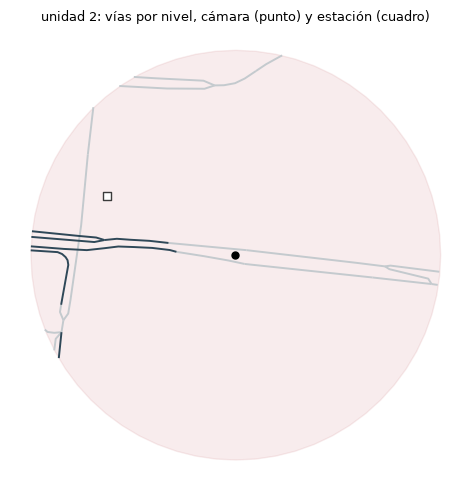

In [11]:
# cómo se ve en el mapa
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_axis_off()

unidad.plot(ax=ax, facecolor="#BC4B51", alpha=.10, edgecolor="#BC4B51", linewidth=1, zorder=1)
recortadas = gpd.GeoSeries(
    [g.intersection(unidad.geometry.iloc[0]) for g in tramos.geometry], crs=tramos.crs
)
for nivel, color in [(0, "#C4CACE"), (1, "#BC4B51"), (-1, "#2F4858"), (2, "#7E2E32"), (-2, "#1F3A4D")]:
    sel = recortadas[tramos.NIVEL.values == nivel]
    if len(sel):
        sel.plot(ax=ax, color=color, linewidth=1.4, zorder=2)

camaras_dentro.plot(ax=ax, color="black", markersize=25, zorder=4)
estaciones_dentro.plot(ax=ax, facecolor="white", edgecolor="#3B3B3B", marker="s", markersize=30, zorder=4)

ax.set_title(f"unidad {EJEMPLO}: vías por nivel, cámara (punto) y estación (cuadro)", fontsize=9)
fig.tight_layout()
plt.show()